---
# Optimisation Clustering Model
---

## Library Imports

In [1]:
# ============================================================================
# LIBRARY IMPORTS
# Import all necessary packages for data manipulation, visualization,
# API requests, and statistical analysis.
# ============================================================================

# To handle dataframe objects
import pandas as pd

# To visualize data and create plots
import matplotlib.pyplot as plt

# To suppress warnings during execution
import warnings

# To perform probability distribution fitting and numerical operations
import numpy as np

import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_samples, silhouette_score

from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [2]:
# Suppress all warnings while executing the code to keep output clean
warnings.filterwarnings('ignore')

## Evaluation Functions

In [3]:
# Cohesion: Mean intra-cluster distance (lower is better)
def compute_cohesion(X, labels, centers):
    cohesion = 0
    for k in range(len(centers)):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            cohesion += np.sum(cdist(cluster_points, [centers[k]]))
    return cohesion / len(X)

# Separation: Mean inter-cluster center distance (higher is better)
def compute_separation(centers):
    if len(centers) < 2:
        return 0
    dists = cdist(centers, centers)
    # Exclude diagonal (self-distance)
    separation = np.sum(dists) - np.trace(dists)
    count = len(centers) * (len(centers) - 1)
    return separation / count

def plot_silhouette(X, labels, n_clusters):
    """
    Create a silhouette plot showing the silhouette coefficient 
    for each sample in each cluster
    """
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Compute silhouette scores for each sample
    silhouette_vals = silhouette_samples(X, labels)
    silhouette_avg = silhouette_score(X, labels)
    
    y_lower = 10
    for i in range(n_clusters):
        # Get silhouette scores for samples in cluster i
        cluster_silhouette_vals = silhouette_vals[labels == i]
        cluster_silhouette_vals.sort()
        
        size_cluster_i = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_silhouette_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10
    
    ax.set_title(f'Silhouette Plot for {n_clusters} Clusters')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster Label')
    
    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", 
               label=f'Average: {silhouette_avg:.3f}')
    ax.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
    
    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xlim([-0.1, 1])
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print cluster-level statistics
    print("\nCluster Silhouette Statistics:")
    print("-" * 50)
    for i in range(n_clusters):
        cluster_silhouette_vals = silhouette_vals[labels == i]
        print(f"Cluster {i}:")
        print(f"  Mean: {cluster_silhouette_vals.mean():.3f}")
        print(f"  Min:  {cluster_silhouette_vals.min():.3f}")
        print(f"  Max:  {cluster_silhouette_vals.max():.3f}")
        print(f"  Samples with negative silhouette: {(cluster_silhouette_vals < 0).sum()}")


---
# Clustering Model
---

### I. K-Means
We will use the elbow method to determine the ideal number of clusters k, then: cluster the data points.

### II. DBSCAN
We will run DBSCAN with changing values of the hyperparameters epsilon and minpoints, then pick the most viable one.

# Loading Data

In [4]:
# Load data
aggregate = pd.read_csv("../../../data/aggregated/clustering-1/aggregate.csv")

# Defining similarity features

We don't need all features to define the similarity metric for clustering, especially ones which are redundant through the linear relationships. (such as reader pressure, utilization score... )

We will select the following features below to prioritise behavior of the reader and not give impact for the copy count itself.

As for the other attributes such as utilization and book categories, we intend to keep the model simple, and we will use the latter attributes in the post cluster analysis to discover hidden insights.

In [5]:
# Features defining similarity between books (STRUCTURAL FEATURES - behavior first)
features = [
    'demand_per_copy',
    'borrowings_duration_avg', 
    'borrowings_duration_std',
    'age',
]

In [6]:
# Check for missing values
print(f"Original data shape: {aggregate.shape}")
print(f"Missing values in features:\n{aggregate[features].isnull().sum()}")

# Handle missing values - fill with median
X = aggregate[features].copy()
for col in features:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

print(f"Data shape after handling missing values: {X.shape}")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Original data shape: (132, 12)
Missing values in features:
demand_per_copy            0
borrowings_duration_avg    0
borrowings_duration_std    0
age                        0
dtype: int64
Data shape after handling missing values: (132, 4)


---
# K-Means
---

## Clustering Formation

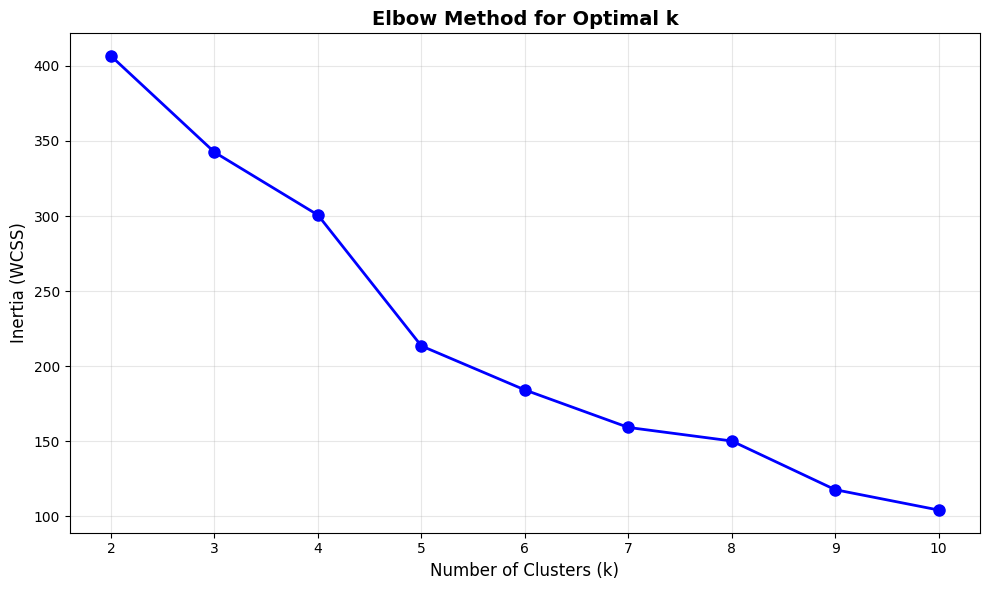

In [7]:
# ============================================================================
# ELBOW METHOD FOR OPTIMAL K SELECTION
# ============================================================================

# Test range of k values
k_range = range(2, 11)
inertias = []  # WCSS (Within-Cluster Sum of Squares)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

plt.tight_layout()
plt.show()

## Inertia Momentum

In [8]:
# Print results table
print("\n" + "="*50)
print("ELBOW METHOD RESULTS")
print("="*50)
print(f"{'k':<5} {'Inertia (WCSS)':<20} {'ΔInertia':<15}")
print("-"*50)

# Calculate inertia differences
for i, (k, inertia) in enumerate(zip(k_range, inertias)):
    if i == 0:
        delta = 0
    else:
        delta = inertias[i-1] - inertia  # How much inertia decreased
    
    print(f"{k:<5} {inertia:<20.2f} {delta:<15.2f}")


ELBOW METHOD RESULTS
k     Inertia (WCSS)       ΔInertia       
--------------------------------------------------
2     406.55               0.00           
3     342.50               64.05          
4     300.70               41.80          
5     213.55               87.15          
6     184.26               29.28          
7     159.29               24.98          
8     150.26               9.03           
9     117.84               32.42          
10    104.29               13.54          


# K := 5

We choose K to be equal to 5, as the momentum of inertia after adding any more clusters gets negligible.

In [9]:
CHOSEN_K = 5

## Performing K-Means

In [10]:
# ============================================================================
# APPLY KMEANS WITH OPTIMAL K
# ============================================================================

kmeans = KMeans(
    n_clusters=CHOSEN_K,
    random_state=42,
    n_init=20
)

aggregate['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Applied KMeans with k={CHOSEN_K}")
print(f"\nCluster Distribution:")
print(aggregate['cluster'].value_counts().sort_index())

Applied KMeans with k=5

Cluster Distribution:
cluster
0    37
1    18
2     5
3    19
4    53
Name: count, dtype: int64


## Cluster Profile Analysis

In [11]:
# ============================================================================
# CLUSTER ANALYSIS: FEATURES, AUTHORS, AND CATEGORIES
# ============================================================================


# Features to analyze
features_to_show = [
    'demand_per_copy',
    'reader_pressure',
    'borrowings_duration_avg',
    'borrowings_duration_std',
    'age',
    'utilization_score'
]

In [12]:
# ===== PART 1: MEAN VALUES FOR EACH FEATURE BY CLUSTER =====
print("="*80)
print("MEAN VALUES FOR EACH CLUSTER")
print("="*80)
mean_values = aggregate.groupby('cluster')[features_to_show].mean().round(3)
print(mean_values)


# Print utilization_score standard deviation statistics
print("\n" + "="*80)
print("UTILIZATION SCORE STANDARD DEVIATION BY CLUSTER")
print("="*80)
utilization_std_stats = aggregate.groupby('cluster')['utilization_score'].std().round(3)
print(utilization_std_stats)

MEAN VALUES FOR EACH CLUSTER
         demand_per_copy  reader_pressure  borrowings_duration_avg  \
cluster                                                              
0                  0.965            0.965                   15.886   
1                  0.486            0.486                   14.157   
2                  0.467            0.467                   13.200   
3                  0.253            0.253                    8.654   
4                  0.350            0.350                   15.603   

         borrowings_duration_std     age  utilization_score  
cluster                                                      
0                          0.221  19.326              0.899  
1                          4.724  14.570              0.068  
2                          0.000  50.600              0.090  
3                          0.380  14.909              0.051  
4                          0.214  11.959              0.293  

UTILIZATION SCORE STANDARD DEVIATION BY CLUST

In [13]:
# ===== PART 2: TOP 3 DOMINANT AUTHORS PER CLUSTER =====
print("\n" + "="*80)
print("TOP 3 DOMINANT AUTHORS BY CLUSTER")
print("="*80)
for cluster_id in sorted(aggregate['cluster'].unique()):
    cluster_data = aggregate[aggregate['cluster'] == cluster_id]
    author_counts = cluster_data['Author'].value_counts()
    total_books = len(cluster_data)
    
    print(f"\nCluster {cluster_id} ({total_books} books):")
    for i, (author, count) in enumerate(author_counts.head(3).items(), 1):
        percentage = (count / total_books) * 100
        print(f"  {i}. {author}: {count} books ({percentage:.1f}%)")


TOP 3 DOMINANT AUTHORS BY CLUSTER

Cluster 0 (37 books):
  1. UNKNOWN_AUTHOR: 3 books (8.1%)
  2. DELANNOY, CLAUDE: 2 books (5.4%)
  3. AASSILA, MOHAMMED: 1 books (2.7%)

Cluster 1 (18 books):
  1. HAZI MOHAMMED: 4 books (22.2%)
  2. MOSELEY,RALPH: 1 books (5.6%)
  3. HAMED C BABA: 1 books (5.6%)

Cluster 2 (5 books):
  1. B DUBUISSON: 1 books (20.0%)
  2. RIVAUD, JACQUES: 1 books (20.0%)
  3. HENICHE .H: 1 books (20.0%)

Cluster 3 (19 books):
  1. HAZI MOHAMMED: 4 books (21.1%)
  2. MARIEB ELAINE: 1 books (5.3%)
  3. DORIGO MARCO: 1 books (5.3%)

Cluster 4 (53 books):
  1. ROSS, SHELDON M.: 1 books (1.9%)
  2. SAHA,SUMAN: 1 books (1.9%)
  3. LYNGSO,SOREN: 1 books (1.9%)


In [14]:
# ===== PART 3: TOP 3 DOMINANT CATEGORIES PER CLUSTER =====
print("\n" + "="*80)
print("TOP 3 DOMINANT CATEGORIES BY CLUSTER")
print("="*80)



# Category mapping
category_labels = {
    0: "teachers",
    1: "first-year students",
    2: "second-year students",
    3: "third-year students",
    4: "fourth-year students"
}

for cluster_id in sorted(aggregate['cluster'].unique()):
    cluster_data = aggregate[aggregate['cluster'] == cluster_id]
    category_counts = cluster_data['category'].value_counts()
    total_books = len(cluster_data)
    
    print(f"\nCluster {cluster_id} ({total_books} books):")
    for i, (category, count) in enumerate(category_counts.head(3).items(), 1):
        percentage = (count / total_books) * 100
        category_name = category_labels.get(category, "unknown")
        print(f"  {i}. Category {category} ({category_name}): {count} books ({percentage:.1f}%)")



TOP 3 DOMINANT CATEGORIES BY CLUSTER

Cluster 0 (37 books):
  1. Category 1 (first-year students): 18 books (48.6%)
  2. Category 2 (second-year students): 7 books (18.9%)
  3. Category 0 (teachers): 6 books (16.2%)

Cluster 1 (18 books):
  1. Category 1 (first-year students): 8 books (44.4%)
  2. Category 3 (third-year students): 6 books (33.3%)
  3. Category 4 (fourth-year students): 2 books (11.1%)

Cluster 2 (5 books):
  1. Category 1 (first-year students): 3 books (60.0%)
  2. Category 2 (second-year students): 1 books (20.0%)
  3. Category 4 (fourth-year students): 1 books (20.0%)

Cluster 3 (19 books):
  1. Category 3 (third-year students): 10 books (52.6%)
  2. Category 4 (fourth-year students): 5 books (26.3%)
  3. Category 2 (second-year students): 4 books (21.1%)

Cluster 4 (53 books):
  1. Category 2 (second-year students): 19 books (35.8%)
  2. Category 1 (first-year students): 12 books (22.6%)
  3. Category 3 (third-year students): 8 books (15.1%)


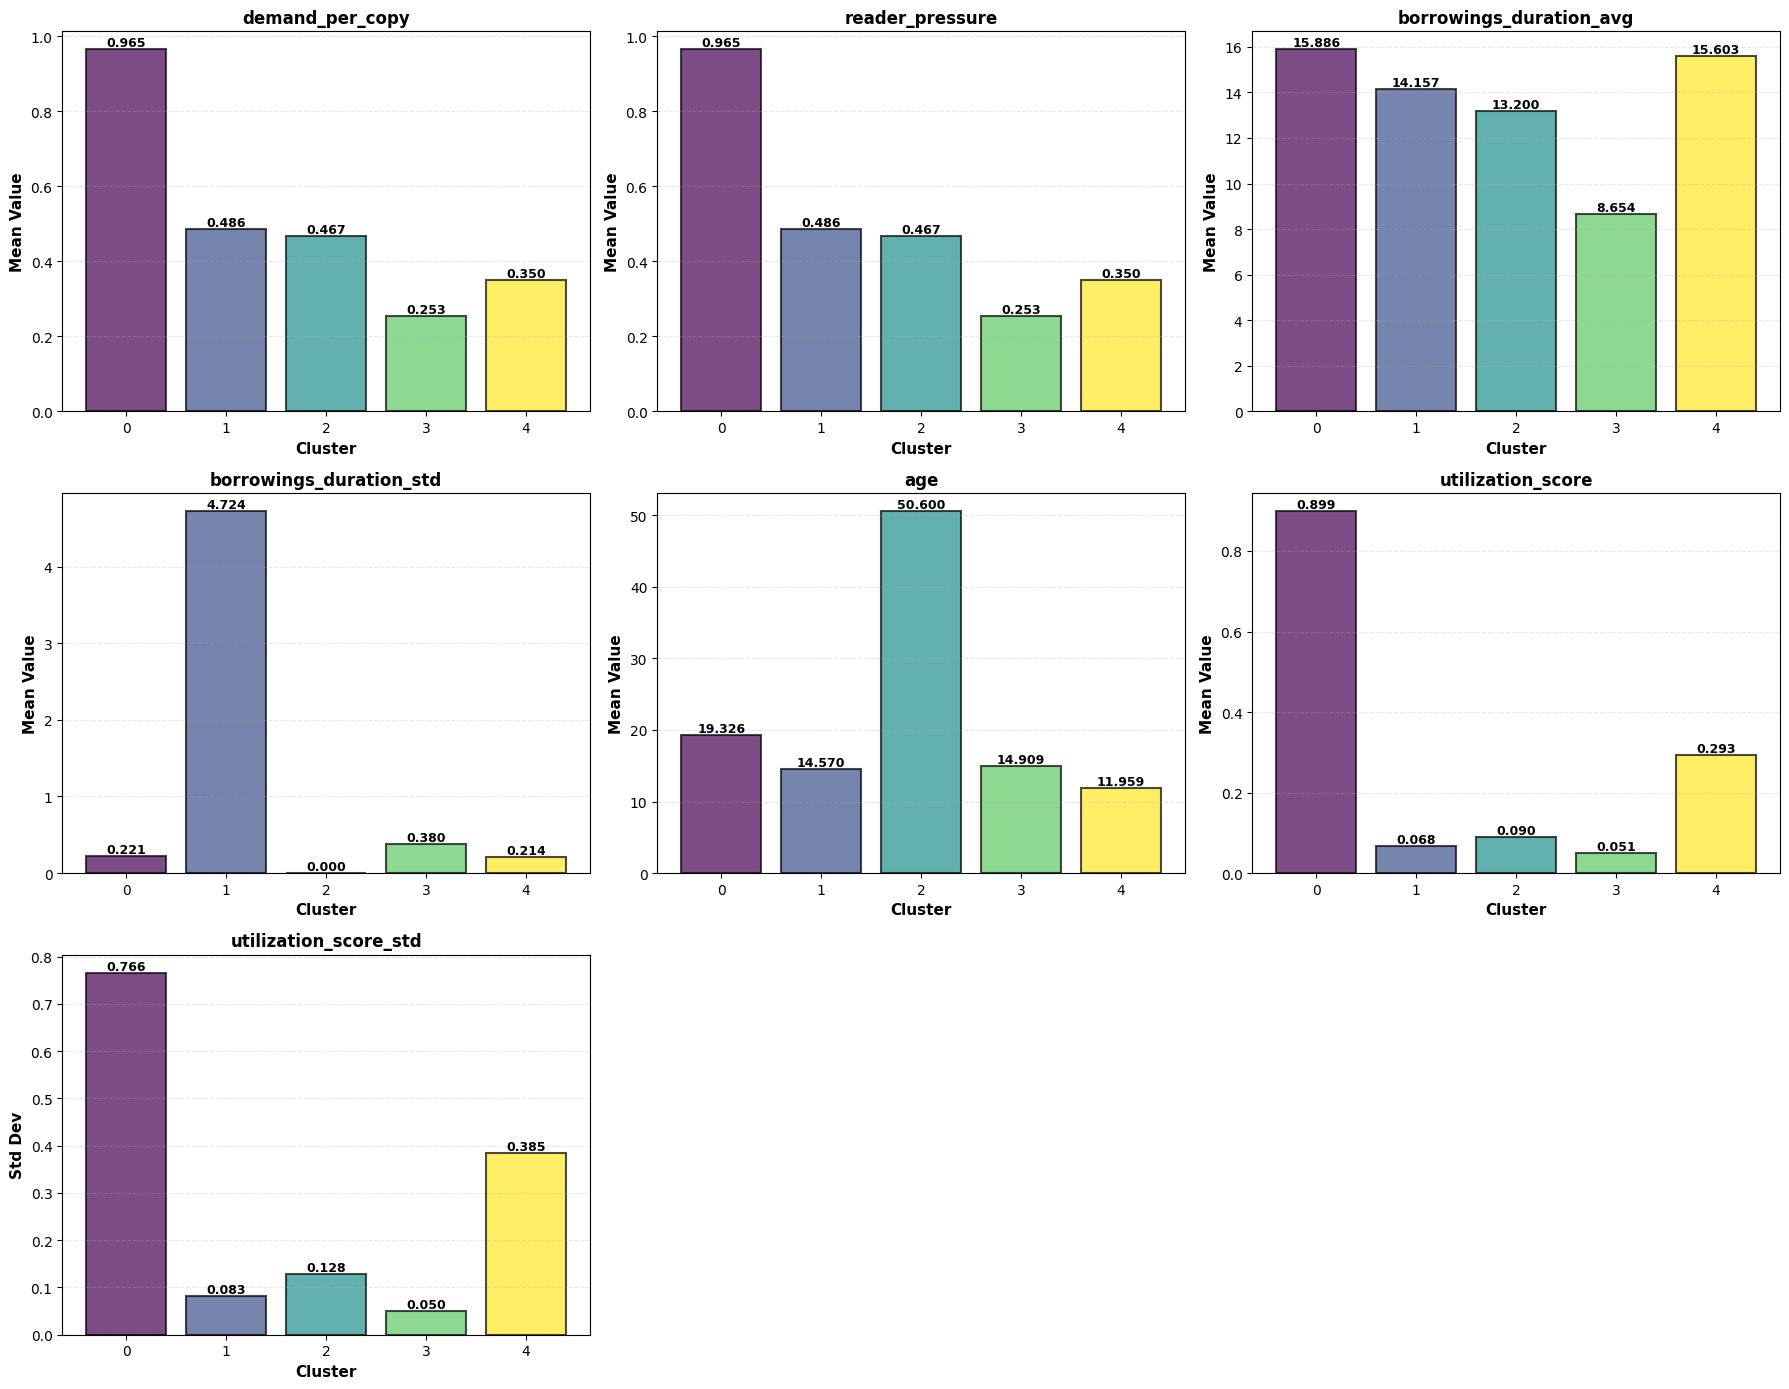

In [15]:
# ===== PART 4: BAR CHARTS FOR FEATURES BY CLUSTER =====
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

clusters = sorted(aggregate['cluster'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

for idx, feature in enumerate(features_to_show):
    ax = axes[idx]
    
    # Extract mean values for this feature across clusters
    feature_means = [aggregate[aggregate['cluster'] == c][feature].mean() for c in clusters]
    
    # Create bar chart
    bars = ax.bar(clusters, feature_means, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on top of bars
    for bar, value in zip(bars, feature_means):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Cluster', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Value', fontsize=11, fontweight='bold')
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticks(clusters)

# ===== ADDITIONAL SUBPLOT: STANDARD DEVIATION OF UTILIZATION SCORE BY CLUSTER =====
ax = axes[6]

# Calculate standard deviation of utilization_score within each cluster
utilization_std = [aggregate[aggregate['cluster'] == c]['utilization_score'].std() for c in clusters]

# Create bar chart for utilization_score std
bars = ax.bar(clusters, utilization_std, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar, value in zip(bars, utilization_std):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Cluster', fontsize=11, fontweight='bold')
ax.set_ylabel('Std Dev', fontsize=11, fontweight='bold')
ax.set_title('utilization_score_std', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(clusters)

# Hide remaining empty subplots
for idx in range(7, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


## K Means Visualisation With PCA

In [16]:
# ============================================================================
# 3D PCA VISUALIZATION WITH DECISION CLASSES
# ============================================================================

# Apply KMeans with 5 clusters
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)
aggregate['cluster'] = cluster_labels

# Apply PCA for 3D visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to dataframe
aggregate['pca1'] = X_pca[:, 0]
aggregate['pca2'] = X_pca[:, 1]
aggregate['pca3'] = X_pca[:, 2]

# Calculate variance explained
variance_explained = pca.explained_variance_ratio_
total_variance_3d = variance_explained.sum()

# Define decision categories based on clusters
def assign_decision(cluster_id):
    if cluster_id == 0:  
        return '0'
    elif cluster_id == 1:  
        return '1'      
    elif cluster_id == 2:
        return '2' 
    elif cluster_id == 3:
        return '3' 
    elif cluster_id == 4:
        return '4' 
    
# Apply decision mapping
aggregate['decision'] = aggregate['cluster'].apply(assign_decision)

# Create 3D PCA plot
fig = px.scatter_3d(
    aggregate,
    x='pca1',
    y='pca2',
    z='pca3',
    color='decision',
    symbol='decision',
    hover_name='Title' if 'Title' in aggregate.columns else 'title',
    hover_data={
        'Author': 'Author' in aggregate.columns,
        'category': 'category' in aggregate.columns,
        'borrowings_count': True,
        'demand_per_copy': True,
        'reader_pressure': True,
        'age': True,
        'cluster': True,
        'borrowings_duration_avg': True,
        'borrowings_duration_std': True
    },
    title=f'3D PCA – Library Book Clusters<br><sup>Variance Explained: {total_variance_3d:.1%} (PC1: {variance_explained[0]:.1%}, PC2: {variance_explained[1]:.1%}, PC3: {variance_explained[2]:.1%})</sup>',
    opacity=0.7,
    size_max=8
)

# Update layout
fig.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({variance_explained[0]:.1%} var)',
        yaxis_title=f'PC2 ({variance_explained[1]:.1%} var)',
        zaxis_title=f'PC3 ({variance_explained[2]:.1%} var)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)  # Adjust 3D view angle
        )
    ),
    legend_title_text='Decision',
    margin=dict(l=0, r=0, b=0, t=60),
    width=1000,
    height=700
)

# Add cluster centers to the plot (optional)
cluster_centers_scaled = kmeans.cluster_centers_
cluster_centers_pca = pca.transform(cluster_centers_scaled)

# Add trace for cluster centers
fig.add_trace(px.scatter_3d(
    pd.DataFrame({
        'pca1': cluster_centers_pca[:, 0],
        'pca2': cluster_centers_pca[:, 1],
        'pca3': cluster_centers_pca[:, 2],
        'cluster': [f'Center {i}' for i in range(CHOSEN_K)]
    }),
    x='pca1',
    y='pca2',
    z='pca3',
    text='cluster'
).data[0].update(
    mode='markers+text',
    marker=dict(
        symbol='diamond',
        size=12,
        color='black',
        line=dict(width=2, color='white')
    ),
    textposition='top center',
    showlegend=False
))

fig.show()

In [17]:
# Print PCA and cluster statistics
print("="*70)
print("3D PCA ANALYSIS WITH DECISION CLASSES")
print("="*70)
print(f"Total variance explained by 3 PCs: {total_variance_3d:.2%}")
print(f"PC1 variance: {variance_explained[0]:.2%}")
print(f"PC2 variance: {variance_explained[1]:.2%}")
print(f"PC3 variance: {variance_explained[2]:.2%}")
print()

# Print cluster distribution
print("CLUSTER DISTRIBUTION:")
print("-"*40)
decision_counts = aggregate['decision'].value_counts()
for decision, count in decision_counts.items():
    percentage = (count / len(aggregate)) * 100
    print(f"{decision}: {count} items ({percentage:.1f}%)")

print()

# Print PCA loadings
print("PCA LOADINGS (Feature Contributions to each PC):")
print("-"*50)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=features
)
print(loadings.round(3))

print()

# Print cluster-to-decision mapping
print("CLUSTER-TO-DECISION MAPPING:")
print("-"*40)
cluster_decision_summary = aggregate.groupby('cluster')['decision'].agg(['first', 'count']).reset_index()
cluster_decision_summary.columns = ['Cluster', 'Decision', 'Count']
print(cluster_decision_summary.to_string(index=False))

3D PCA ANALYSIS WITH DECISION CLASSES
Total variance explained by 3 PCs: 86.58%
PC1 variance: 34.52%
PC2 variance: 27.53%
PC3 variance: 24.53%

CLUSTER DISTRIBUTION:
----------------------------------------
0: 57 items (43.2%)
2: 35 items (26.5%)
3: 20 items (15.2%)
1: 16 items (12.1%)
4: 4 items (3.0%)

PCA LOADINGS (Feature Contributions to each PC):
--------------------------------------------------
                           PC1    PC2    PC3
demand_per_copy          0.736  0.019  0.110
borrowings_duration_avg  0.546 -0.606 -0.090
borrowings_duration_std -0.149 -0.291  0.945
age                      0.370  0.740  0.295

CLUSTER-TO-DECISION MAPPING:
----------------------------------------
 Cluster Decision  Count
       0        0     57
       1        1     16
       2        2     35
       3        3     20
       4        4      4


## KMEANS Clustering Evaluation

In [18]:
# Clustering Evaluation

# Silhouette Coefficient: [-1, 1], higher is better
silhouette_avg = silhouette_score(X_scaled, aggregate['cluster'])
print(f"Silhouette Coefficient (mean): {silhouette_avg:.3f}")

# Compute cohesion and separation
cohesion = compute_cohesion(X_scaled, aggregate['cluster'].values, kmeans.cluster_centers_)
separation = compute_separation(kmeans.cluster_centers_)

print(f"Cohesion (mean intra-cluster distance): {cohesion:.3f}")
print(f"Separation (mean inter-cluster center distance): {separation:.3f}")

Silhouette Coefficient (mean): 0.350
Cohesion (mean intra-cluster distance): 1.085
Separation (mean inter-cluster center distance): 3.264


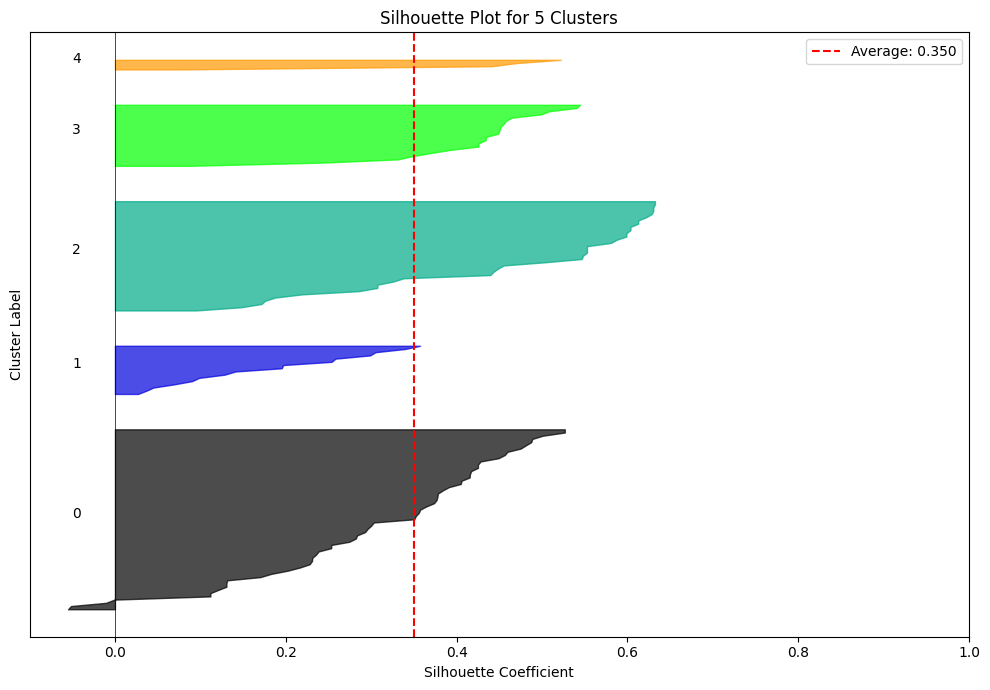


Cluster Silhouette Statistics:
--------------------------------------------------
Cluster 0:
  Mean: 0.304
  Min:  -0.055
  Max:  0.527
  Samples with negative silhouette: 4
Cluster 1:
  Mean: 0.178
  Min:  0.027
  Max:  0.357
  Samples with negative silhouette: 0
Cluster 2:
  Mean: 0.462
  Min:  0.095
  Max:  0.632
  Samples with negative silhouette: 0
Cluster 3:
  Mean: 0.416
  Min:  0.086
  Max:  0.545
  Samples with negative silhouette: 0
Cluster 4:
  Mean: 0.377
  Min:  0.074
  Max:  0.522
  Samples with negative silhouette: 0


In [19]:
labels = aggregate['cluster'].values

plot_silhouette(X_scaled, labels, n_clusters=5)

The clusters with the best qualities are 3 and 2, while 0 and 1 have inconsistent silhouette scores with respect to the width in their plots, and cluster 4 is too small for interpretation.

---
# DBSCAN
---

In [20]:
# ============================================================================
# DBSCAN CLUSTERING
# ============================================================================

# ============================================================================
# FIND OPTIMAL EPSILON USING K-DISTANCE GRAPH
# ============================================================================

# Calculate k-distances to find elbow point
k = 4  # minPts parameter (typically = dimensionality)
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, k-1], axis=0)

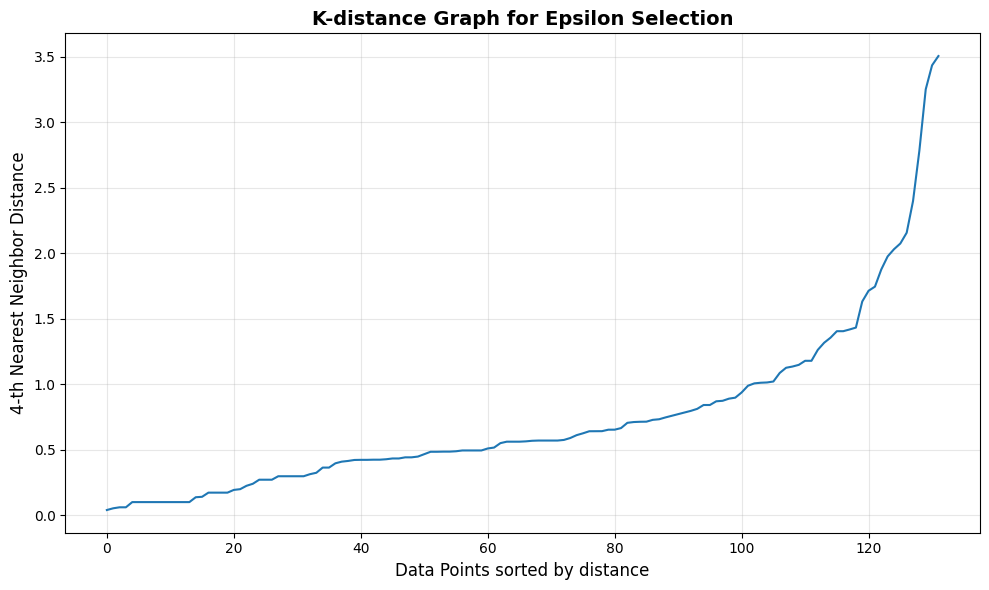

K-distance values (sample of last 20):
[1.26117367 1.31539309 1.35384064 1.40348739 1.40348739 1.4165529
 1.43099007 1.63022214 1.71230609 1.74371345 1.87494528 1.97428152
 2.02925751 2.07299559 2.15520392 2.39697653 2.78223057 3.25011593
 3.43347155 3.5042401 ]

Suggested epsilon range: 1.431 to 2.073


In [21]:
# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel('4-th Nearest Neighbor Distance', fontsize=12)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.title('K-distance Graph for Epsilon Selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estimate epsilon from the elbow
print("K-distance values (sample of last 20):")
print(distances[-20:])
print(f"\nSuggested epsilon range: {distances[int(len(distances)*0.9)]:.3f} to {distances[int(len(distances)*0.95)]:.3f}")

In [22]:
# ============================================================================
# TEST DIFFERENT EPSILON AND MIN_SAMPLES VALUES
# ============================================================================

epsilon_values = []
eps_init = 0
for i in range(200):
    eps_init = eps_init + .1
    epsilon_values.append(eps_init)

min_samples_values = []
min_int = 1
for i in range(200):
    min_int = min_int + 1
    min_samples_values.append(min_int)

results = []

print("\n" + "="*80)
print("DBSCAN PARAMETER TESTING")
print("="*80)
print(f"{'Epsilon':<12} {'MinSamples':<15} {'Clusters':<12} {'Noise Points':<15} {'Silhouette':<15}")
print("-"*80)

for eps in epsilon_values:
    for min_samp in min_samples_values:
        # Apply DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X_scaled)
        
        # Count clusters and noise points
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Calculate silhouette score (skip if too few clusters or too many noise points)
        if n_clusters > 1 and n_noise < len(labels) * 0.5:
            silhouette_avg = silhouette_score(X_scaled, labels)
        else:
            silhouette_avg = -1
        
        print(f"{eps:<12.1f} {min_samp:<15} {n_clusters:<12} {n_noise:<15} {silhouette_avg:<15.3f}")
        
        results.append({
            'epsilon': eps,
            'min_samples': min_samp,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': silhouette_avg
        })


DBSCAN PARAMETER TESTING
Epsilon      MinSamples      Clusters     Noise Points    Silhouette     
--------------------------------------------------------------------------------
0.1          2               16           87              -1.000         
0.1          3               4            111             -1.000         
0.1          4               2            117             -1.000         
0.1          5               2            121             -1.000         
0.1          6               0            132             -1.000         
0.1          7               0            132             -1.000         
0.1          8               0            132             -1.000         
0.1          9               0            132             -1.000         
0.1          10              0            132             -1.000         
0.1          11              0            132             -1.000         
0.1          12              0            132             -1.000         
0.1  

In [23]:


# ============================================================================
# APPLY OPTIMAL DBSCAN
# ============================================================================

# Select best parameters (balance between cluster quality and noise handling)
results_df = pd.DataFrame(results)
# Find best result: max silhouette with reasonable cluster count and low noise
best_result = results_df[(results_df['n_clusters'] > 1) & 
                         (results_df['n_noise'] < len(labels) * 0.3)].nlargest(1, 'silhouette')

if len(best_result) > 0:
    best_eps = float(best_result.iloc[0]['epsilon'])
    best_min_samp = int(best_result.iloc[0]['min_samples'])  # Convert to int
else:
    # Fallback to reasonable defaults
    best_eps = 0.5
    best_min_samp = 4

print(f"\n{'='*80}")
print(f"OPTIMAL PARAMETERS: eps={best_eps}, min_samples={best_min_samp}")
print(f"{'='*80}\n")

# Apply DBSCAN with optimal parameters
dbscan_optimal = DBSCAN(eps=best_eps, min_samples=best_min_samp)
aggregate['dbscan_cluster'] = dbscan_optimal.fit_predict(X_scaled)

# Print cluster distribution
print("DBSCAN Cluster Distribution:")
print("-" * 50)
cluster_counts = pd.Series(aggregate['dbscan_cluster']).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    if cluster_id == -1:
        print(f"Noise Points: {count} ({count/len(aggregate)*100:.1f}%)")
    else:
        print(f"Cluster {cluster_id}: {count} items ({count/len(aggregate)*100:.1f}%)")


OPTIMAL PARAMETERS: eps=2.700000000000001, min_samples=2

DBSCAN Cluster Distribution:
--------------------------------------------------
Cluster 0: 2 items (1.5%)
Cluster 1: 130 items (98.5%)


In [24]:
# ============================================================================
# ANALYZE DBSCAN CLUSTERS
# ============================================================================

print("\n" + "="*70)
print("DBSCAN CLUSTER CHARACTERISTICS")
print("="*70)

features_to_show = [
    'demand_per_copy',
    'reader_pressure',
    'borrowings_duration_avg',
    'borrowings_duration_std',
    'age',
    'utilization_score'
]

# Calculate mean values for each cluster (excluding noise points)
valid_clusters = aggregate[aggregate['dbscan_cluster'] != -1]
print("\nMean values for each cluster (excluding noise):")
print(valid_clusters.groupby('dbscan_cluster')[features_to_show].mean().round(3))

# Print noise point statistics
noise_points = aggregate[aggregate['dbscan_cluster'] == -1]
if len(noise_points) > 0:
    print("\n" + "-"*70)
    print("NOISE POINTS (Outliers) Statistics:")
    print("-"*70)
    print(noise_points[features_to_show].describe().round(3))


DBSCAN CLUSTER CHARACTERISTICS

Mean values for each cluster (excluding noise):
                demand_per_copy  reader_pressure  borrowings_duration_avg  \
dbscan_cluster                                                              
0                         1.000            1.000                   31.000   
1                         0.524            0.524                   14.138   

                borrowings_duration_std     age  utilization_score  
dbscan_cluster                                                      
0                                  0.00  12.000              2.583  
1                                  0.86  16.334              0.356  


## DBSCAN Visualisation With PCA

In [25]:
# ============================================================================
# 3D PCA VISUALIZATION FOR DBSCAN CLUSTERING
# ============================================================================

# Handle missing values
X = aggregate[features].copy()
for col in features:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

# Apply PCA for 3D visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to dataframe
aggregate['pca1'] = X_pca[:, 0]
aggregate['pca2'] = X_pca[:, 1]
aggregate['pca3'] = X_pca[:, 2]

# Calculate variance explained
variance_explained = pca.explained_variance_ratio_
total_variance_3d = variance_explained.sum()

# Define decision categories based on DBSCAN clusters
def assign_dbscan_decision(cluster_id):
    if cluster_id == -1:  
        return 'Outlier'
    else:
        return f'Cluster_{int(cluster_id)}'
    
# Apply decision mapping for DBSCAN
aggregate['dbscan_decision'] = aggregate['dbscan_cluster'].apply(assign_dbscan_decision)

In [26]:
# Create 3D PCA plot for DBSCAN
fig = px.scatter_3d(
    aggregate,
    x='pca1',
    y='pca2',
    z='pca3',
    color='dbscan_decision',
    symbol='dbscan_decision',
    hover_name='Title' if 'Title' in aggregate.columns else 'title',
    hover_data={
        'Author': 'Author' in aggregate.columns,
        'category': 'category' in aggregate.columns,
        'borrowings_count': True,
        'demand_per_copy': True,
        'reader_pressure': True,
        'age': True,
        'dbscan_cluster': True,
        'borrowings_duration_avg': True,
        'borrowings_duration_std': True
    },
    title=f'3D PCA – DBSCAN Book Clusters<br><sup>Variance Explained: {total_variance_3d:.1%} (PC1: {variance_explained[0]:.1%}, PC2: {variance_explained[1]:.1%}, PC3: {variance_explained[2]:.1%})</sup>',
    opacity=0.7,
    size_max=8
)

# Update layout
fig.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({variance_explained[0]:.1%} var)',
        yaxis_title=f'PC2 ({variance_explained[1]:.1%} var)',
        zaxis_title=f'PC3 ({variance_explained[2]:.1%} var)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    legend_title_text='DBSCAN Cluster',
    margin=dict(l=0, r=0, b=0, t=60),
    width=1000,
    height=700
)

fig.show()

In [27]:
# Print PCA and DBSCAN statistics
print("="*70)
print("3D PCA ANALYSIS WITH DBSCAN CLUSTERING")
print("="*70)
print(f"Total variance explained by 3 PCs: {total_variance_3d:.2%}")
print(f"PC1 variance: {variance_explained[0]:.2%}")
print(f"PC2 variance: {variance_explained[1]:.2%}")
print(f"PC3 variance: {variance_explained[2]:.2%}")
print()

# Print DBSCAN cluster distribution
print("DBSCAN CLUSTER DISTRIBUTION:")
print("-"*40)
dbscan_counts = aggregate['dbscan_decision'].value_counts()
for decision, count in dbscan_counts.items():
    percentage = (count / len(aggregate)) * 100
    print(f"{decision}: {count} items ({percentage:.1f}%)")

print()

# Print PCA loadings
print("PCA LOADINGS (Feature Contributions to each PC):")
print("-"*50)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=features
)
print(loadings.round(3))

print()

# Print cluster characteristics
print("DBSCAN CLUSTER CHARACTERISTICS IN PCA SPACE:")
print("-"*50)
pca_summary = aggregate.groupby('dbscan_cluster')[['pca1', 'pca2', 'pca3']].mean()
print(pca_summary.round(3))

3D PCA ANALYSIS WITH DBSCAN CLUSTERING
Total variance explained by 3 PCs: 86.58%
PC1 variance: 34.52%
PC2 variance: 27.53%
PC3 variance: 24.53%

DBSCAN CLUSTER DISTRIBUTION:
----------------------------------------
Cluster_1: 130 items (98.5%)
Cluster_0: 2 items (1.5%)

PCA LOADINGS (Feature Contributions to each PC):
--------------------------------------------------
                           PC1    PC2    PC3
demand_per_copy          0.736  0.019  0.110
borrowings_duration_avg  0.546 -0.606 -0.090
borrowings_duration_std -0.149 -0.291  0.945
age                      0.370  0.740  0.295

DBSCAN CLUSTER CHARACTERISTICS IN PCA SPACE:
--------------------------------------------------
                 pca1   pca2   pca3
dbscan_cluster                     
0               3.455 -2.967 -0.844
1              -0.053  0.046  0.013


## DBSCAN Clustering Evaluation

In [28]:
# DBSCAN Clustering Evaluation

dbscan_labels = aggregate['dbscan_cluster'].values

# Silhouette Coefficient: [-1, 1], higher is better (only for non-noise points)
# Filter out noise points (labeled as -1) for silhouette score
valid_mask = dbscan_labels != -1
if valid_mask.sum() > 1:  # Need at least 2 points
    silhouette_avg = silhouette_score(X_scaled[valid_mask], dbscan_labels[valid_mask])
    print(f"Silhouette Coefficient (mean): {silhouette_avg:.3f}")
else:
    print("Not enough non-noise points for Silhouette Coefficient")

# Compute cohesion and separation from DBSCAN clusters
# Calculate cluster centers from DBSCAN cluster assignments
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

if n_clusters > 0:
    # Compute centers for each DBSCAN cluster (excluding noise points)
    dbscan_centers = []
    for cluster_id in sorted(set(dbscan_labels)):
        if cluster_id != -1:  # Skip noise points
            cluster_mask = dbscan_labels == cluster_id
            center = X_scaled[cluster_mask].mean(axis=0)
            dbscan_centers.append(center)
    
    dbscan_centers = np.array(dbscan_centers)
    
    # Compute cohesion and separation
    cohesion = compute_cohesion(X_scaled, dbscan_labels, dbscan_centers)
    separation = compute_separation(dbscan_centers)
    
    print(f"\nCohesion (mean intra-cluster distance): {cohesion:.3f}")
    print(f"Separation (mean inter-cluster center distance): {separation:.3f}")
else:
    print("\nNo valid clusters for cohesion/separation calculation")

print(f"\nNumber of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

Silhouette Coefficient (mean): 0.535

Cohesion (mean intra-cluster distance): 1.705
Separation (mean inter-cluster center distance): 4.961

Number of clusters: 2
Number of noise points: 0 (0.0%)


---
# Comparison Between K Means & DBSCAN
---
We performed a visual analysis and a numerical evaluation on both clustering methods:

| Evaluation Metric | K Means | DBSCAN |
|-----------|-------------|--------|
| Cohesion | 1.085 | 1.705 |
| Separation | 3.264 | 4.961 |
| Silhouette Coefficient | 0.350 | 0.535 |

Even though DBSCAN outperforms K-means in both separation and silhouette coefficient, but the resulting clustering model is very bad in terms of decision making and also doesn't have any valuable interpretation.

DBSCAN clustered most of the data instances in one cluster, because of the epsilon and minpoints parameters that were evaluated from the silhouette score:
### eps=2.700000000000001, min_samples=2
This clustering is bad because the manifold formed by the data points is not density based, which is why K-means performs better in term of interpretability and insight.
K means seperates 5 clusters and gives them unique and distinct profiles, better for interpretation and decision making on the business side.

Hence, we will adopt K-means in the decision making of the library optimisation.








---
# Interpreting The Results
---


# Geometric Mixture Classification Summary

## Optimisation Pillars

This analysis bridges **three analytical dimensions** to solve the library optimization problem:

1. **Clustering** → Reveals structural similarities between books
2. **Geometric Mixture Model** → Classifies books into "low-copy" vs "high-copy" demand regimes
3. **Utilization Efficiency** → Measures how well current inventory serves demand

## How It Works

### The Geometric Mixture Model

In the preprocessing and EDA of the inventory dataset, we fitted a probability distribution of a geometric mixture onto the copy count attribute:

---
**Geometric Mixture PMF:**
P(X = k) = w · p₁ · (1 − p₁)^(k−1) + (1 − w) · p₂ · (1 − p₂)^(k−1)

Where:
- w = 0.071 (mixing weight)
- p₁ = 0.018 (Component 1 success probability)
- p₂ = 0.401 (Component 2 success probability)

**Component Means:**
- E[X|Component 1] = 1/p₁ = 56.2
- E[X|Component 2] = 1/p₂ = 2.5
- Overall mean = w × 56.2 + (1-w) × 2.5 = 6.3
---
- **Component 1 (Low-copy regime)**: $p_1 = 0.018$, weight $w = 0.071$
  - Interpretation: ~7% of books are specialized, need few copies, borrowed slowly
  - Mean copies needed: ~56

- **Component 2 (High-copy regime)**: $p_2 = 0.401$, weight $1-w = 0.929$
  - Interpretation: ~93% of books are general use, need many copies, borrowed quickly
  - Mean copies needed: ~2.5
---

### Converting Demand to Geometry

For each book/cluster with `demand_per_copy`, we compute:

$$k = \frac{1}{\text{demand\_per\_copy}}$$

This represents the **effective number of copies required** to satisfy observed demand.

### Bayesian Classification

We compute posterior probabilities:

$$P(\text{Low-copy} \mid k) \propto w \cdot p_1(1-p_1)^{k-1}$$

$$P(\text{High-copy} \mid k) \propto (1-w) \cdot p_2(1-p_2)^{k-1}$$

**Classify** by whichever posterior is larger.

## Decision Matrix

| Copy Class | Utilization | Action |
|-----------|-------------|--------|
| High-copy | High (>50%) | **ACQUIRE MORE** |
| High-copy | Moderate (20-50%) | **MAINTAIN** |
| High-copy | Low (<20%) | **INVESTIGATE** |
| Low-copy | High (>50%) | **KEEP MINIMAL** |
| Low-copy | Moderate (20-50%) | **AUDIT CURRICULUM** |
| Low-copy | Low (<15%) | **DEACCESSION** |


- `aggregate_with_pca_decisions.csv` — Clusters with PCA visualization coordinates
- `aggregate_with_copy_class.csv` — Per-book geometric mixture classifications
- Visualizations: Decision map showing optimal actions by cluster


In [29]:
# ============================================================================
# GEOMETRIC MIXTURE MODEL CLASSIFICATION AT CLUSTER LEVEL
# ============================================================================
# This bridges clustering with geometric demand modeling
# Each cluster is classified as "Low-copy" or "High-copy" based on Bayesian inference

# Geometric mixture parameters (from prior modeling)
w = 0.071          # Weight of low-copy component
p1 = 0.018         # Parameter for low-copy component (slow-demand, ~56 copies mean)
p2 = 0.401         # Parameter for high-copy component (fast-demand, ~2.5 copies mean)

def geometric_pmf(k, p):
    """
    Geometric probability mass function: P(X=k) = p(1-p)^(k-1)
    
    k: effective required copies (1/demand_per_copy)
    p: success probability parameter
    """
    # Avoid numerical issues with very small k values
    return p * np.power(1 - p, np.maximum(k - 1, 0))

def classify_cluster_copy_regime(mean_demand_per_copy):
    """
    Classify a cluster into copy regime using Bayesian geometric mixture model
    
    Returns:
        - label: "Low-copy" or "High-copy"
        - low_post: posterior probability of low-copy regime
        - high_post: posterior probability of high-copy regime
        - k: effective required copies (1/demand_per_copy)
    """
    # Convert demand_per_copy to geometric k
    # k = 1/demand_per_copy means: "how many copies needed per unit demand"
    k = 1.0 / mean_demand_per_copy if mean_demand_per_copy > 0 else np.inf
    
    # Compute likelihoods from each component
    low_likelihood = w * geometric_pmf(k, p1)
    high_likelihood = (1 - w) * geometric_pmf(k, p2)
    
    # Normalize to get posterior probabilities
    total = low_likelihood + high_likelihood
    if total > 0:
        low_post = low_likelihood / total
        high_post = high_likelihood / total
    else:
        low_post = w
        high_post = 1 - w
    
    # Classify by maximum posterior
    label = "Low-copy" if low_post > high_post else "High-copy"
    
    return label, low_post, high_post, k

In [30]:
# Prepare cluster-level summary statistics
cluster_means = aggregate.groupby('cluster')[features_to_show].mean()

# Apply geometric mixture classification
results = []

print("="*100)
print("GEOMETRIC MIXTURE MODEL: CLUSTER COPY REGIME CLASSIFICATION")
print("="*100)
print(f"\nModel Parameters:")
print(f"  Low-copy component:  w={w:.3f}, p₁={p1:.3f} (mean={1/p1:.1f} copies)")
print(f"  High-copy component: w={1-w:.3f}, p₂={p2:.3f} (mean={1/p2:.1f} copies)")
print()

for cluster_id in sorted(aggregate['cluster'].unique()):
    cluster_data = aggregate[aggregate['cluster'] == cluster_id]
    
    mean_demand = cluster_means.loc[cluster_id, 'demand_per_copy']
    mean_utilization = cluster_means.loc[cluster_id, 'utilization_score']
    n_books = len(cluster_data)
    
    # Classify using geometric mixture
    label, low_post, high_post, k = classify_cluster_copy_regime(mean_demand)
    
    results.append({
        "Cluster": cluster_id,
        "N_Books": n_books,
        "Mean_Demand": mean_demand,
        "Copy_Class": label,
        "P(Low-copy)": low_post,
        "P(High-copy)": high_post,
        "k_required": k,
        "Mean_Utilization": mean_utilization
    })
    
    print(f"Cluster {cluster_id}:")
    print(f"  Books: {n_books} | Demand/copy: {mean_demand:.3f} | k = {k:.3f}")
    print(f"  Classification: {label}")
    print(f"  P(Low-copy)  = {low_post:.3f}")
    print(f"  P(High-copy) = {high_post:.3f}")
    print()

# Create results dataframe
cluster_copy_classes = pd.DataFrame(results).set_index("Cluster")
print(cluster_copy_classes.to_string())

# ============================================================================
# DECISION MATRIX: COMBINING CLUSTERING, COPY CLASS, AND UTILIZATION
# ============================================================================

print("\n" + "="*100)
print("DECISION MATRIX: CLUSTER-LEVEL ACTIONS")
print("="*100)
print()

decision_matrix = []

for cluster_id in sorted(aggregate['cluster'].unique()):
    row = cluster_copy_classes.loc[cluster_id]
    cluster_data = aggregate[aggregate['cluster'] == cluster_id]
    
    n_books = row['N_Books']
    copy_class = row['Copy_Class']
    utilization = row['Mean_Utilization']
    p_high = row['P(High-copy)']
    demand = row['Mean_Demand']
    
    # Decision logic matrix
    if copy_class == "High-copy":
        if utilization > 0.5:
            action = "ACQUIRE MORE"
            rationale = "High demand + high efficiency → scale up"
        elif utilization > 0.2:
            action = "MAINTAIN"
            rationale = "High demand + moderate efficiency → keep current stock"
        else:
            action = "INVESTIGATE"
            rationale = "High demand but low efficiency → check for issues"
    else:  # Low-copy
        if utilization > 0.5:
            action = "KEEP MINIMAL"
            rationale = "Low demand + high efficiency → specialized, keep 1-2 copies"
        elif utilization > 0.2:
            action = "REVIEW CURRICULUM"
            rationale = "Low demand + moderate efficiency → verify if still needed"
        else:
            action = "ARCHIVE"
            rationale = "Low demand + low efficiency → not serving library goals"
    
    decision_matrix.append({
        "Cluster": cluster_id,
        "Books": n_books,
        "Copy_Class": copy_class,
        "P(High-copy)": f"{p_high:.2%}",
        "Utilization": f"{utilization:.2%}",
        "Action": action,
        "Rationale": rationale
    })

decision_df = pd.DataFrame(decision_matrix)

print("DECISION RECOMMENDATIONS:")
print("-" * 100)
for _, row in decision_df.iterrows():
    print(f"\nCluster {int(row['Cluster'])} [{row['Books']} books]")
    print(f"  Copy Class:    {row['Copy_Class']} (P={row['P(High-copy)']})")
    print(f"  Utilization:   {row['Utilization']}")
    print(f"  Action:        {row['Action']}")
    print(f"  Rationale:     {row['Rationale']}")

print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)
print(decision_df.to_string(index=False))


GEOMETRIC MIXTURE MODEL: CLUSTER COPY REGIME CLASSIFICATION

Model Parameters:
  Low-copy component:  w=0.071, p₁=0.018 (mean=55.6 copies)
  High-copy component: w=0.929, p₂=0.401 (mean=2.5 copies)

Cluster 0:
  Books: 57 | Demand/copy: 0.386 | k = 2.594
  Classification: High-copy
  P(Low-copy)  = 0.007
  P(High-copy) = 0.993

Cluster 1:
  Books: 16 | Demand/copy: 0.422 | k = 2.372
  Classification: High-copy
  P(Low-copy)  = 0.007
  P(High-copy) = 0.993

Cluster 2:
  Books: 35 | Demand/copy: 0.980 | k = 1.021
  Classification: High-copy
  P(Low-copy)  = 0.003
  P(High-copy) = 0.997

Cluster 3:
  Books: 20 | Demand/copy: 0.266 | k = 3.763
  Classification: High-copy
  P(Low-copy)  = 0.013
  P(High-copy) = 0.987

Cluster 4:
  Books: 4 | Demand/copy: 0.458 | k = 2.182
  Classification: High-copy
  P(Low-copy)  = 0.006
  P(High-copy) = 0.994

         N_Books  Mean_Demand Copy_Class  P(Low-copy)  P(High-copy)  k_required  Mean_Utilization
Cluster                                          

## VISUALIZATION: COPY CLASS × UTILIZATION DECISION MAP

### Interpretation:

- **X-axis:** Utilization Score (how efficiently copies are being used)
- **Y-axis:** P(High-copy) from geometric mixture model (probability of high-demand regime)
- **Size:** Number of books in cluster
- **Color:** Classification from Bayesian inference

### Zones (Top = High-copy, Bottom = Low-copy):

- **Top-right:** HIGH-COPY + HIGH UTILIZATION → **ACQUIRE MORE** copies
- **Top-middle:** HIGH-COPY + MODERATE UTILIZATION → **MAINTAIN** current stock
- **Top-left:** HIGH-COPY + LOW UTILIZATION → **INVESTIGATE** issues
- **Bottom-right:** LOW-COPY + HIGH UTILIZATION → **KEEP MINIMAL** (specialized)
- **Bottom-middle:** LOW-COPY + MODERATE UTILIZATION → **REVIEW CURRICULUM**
- **Bottom-left:** LOW-COPY + LOW UTILIZATION → **ARCHIVE** (deaccession)

In [31]:
# ============================================================================
# VISUALIZATION: COPY CLASS × UTILIZATION DECISION MAP
# ============================================================================

# Create decision landscape visualization
fig = px.scatter(
    cluster_copy_classes.reset_index(),
    x='Mean_Utilization',
    y='P(High-copy)',
    size='N_Books',
    color='Copy_Class',
    hover_name='Cluster',
    hover_data={
        'N_Books': True,
        'Mean_Demand': ':.3f',
        'k_required': ':.3f',
        'Mean_Utilization': ':.3f',
        'P(Low-copy)': ':.3f',
        'P(High-copy)': ':.3f',
        'Copy_Class': True
    },
    color_discrete_map={'Low-copy': '#FF6B6B', 'High-copy': '#4ECDC4'},
    title='Cluster Decision Map: Copy Class × Utilization Landscape',
    labels={
        'Mean_Utilization': 'Utilization Score',
        'P(High-copy)': 'Probability of High-Copy Demand',
        'N_Books': 'Number of Books'
    },
    size_max=50
)

# Add decision zones
fig.add_hline(y=0.5, line_dash="dash", line_color="gray", opacity=0.5, 
              annotation_text="Copy Class Boundary (50%)")
# Utilization bands
fig.add_vline(x=0.2, line_dash="dot", line_color="gray", opacity=0.4,
              annotation_text="Low Utilization")

fig.add_vline(x=0.6, line_dash="dot", line_color="gray", opacity=0.4,
              annotation_text="High Utilization")


# Annotate zones - Top row (High P(High-copy) = High-copy classification)
fig.add_annotation(
    x=0.8, y=0.9, text="ACQUIRE MORE<br>High-copy + High use",
    showarrow=False, bgcolor="rgba(76, 205, 196, 0.15)",
    bordercolor="#4ECDC4", borderwidth=2, borderpad=10
)

fig.add_annotation(
    x=0.4, y=0.9, text="MAINTAIN<br>High-copy + Moderate use",
    showarrow=False, bgcolor="rgba(100, 149, 237, 0.15)",
    bordercolor="#6495ED", borderwidth=2, borderpad=10
)

fig.add_annotation(
    x=0.1, y=0.9, text="INVESTIGATE<br>High-copy + Low use",
    showarrow=False, bgcolor="rgba(255, 152, 0, 0.15)",
    bordercolor="#FF9800", borderwidth=2, borderpad=10
)

# Annotate zones - Bottom row (Low P(High-copy) = Low-copy classification)
fig.add_annotation(
    x=0.8, y=0.1, text="KEEP MINIMAL<br>Low-copy + High use",
    showarrow=False, bgcolor="rgba(255, 193, 7, 0.15)",
    bordercolor="#FFC107", borderwidth=2, borderpad=10
)

fig.add_annotation(
    x=0.4, y=0.1, text="REVIEW CURRICULUM<br>Low-copy + Moderate use",
    showarrow=False, bgcolor="rgba(156, 39, 176, 0.15)",
    bordercolor="#9C27B0", borderwidth=2, borderpad=10
)

fig.add_annotation(
    x=0.1, y=0.1, text="ARCHIVE<br>Low-copy + Low use",
    showarrow=False, bgcolor="rgba(244, 67, 54, 0.15)",
    bordercolor="#F44336", borderwidth=2, borderpad=10
)


fig.update_layout(
    height=700,
    width=1000,
    showlegend=True,
    hovermode='closest'
)

fig.show()

In [34]:
# ============================================================================
# PER-BOOK POSTERIOR CLASSIFICATION (OPTIONAL BUT POWERFUL)
# ============================================================================
# Extend the geometric mixture classification to individual books
# This allows per-title decision-making within clusters


# Apply classification to each book in aggregate
book_results = []

for idx, book in aggregate.iterrows():
    cluster_id = book['cluster']
    mean_demand = book['demand_per_copy']
    
    # Classify each book individually
    label, low_post, high_post, k = classify_cluster_copy_regime(mean_demand)
    
    book_results.append({
        'title': book['Title'] if 'Title' in book.index else book.get('title', 'Unknown'),
        'cluster': cluster_id,
        'demand_per_copy': mean_demand,
        'copy_class': label,
        'P_low_copy': low_post,
        'P_high_copy': high_post,
        'k_required': k,
        'utilization_score': book['utilization_score'],
        'age': book['age'],
        'borrowings_count': book['borrowings_count']
    })

book_classification = pd.DataFrame(book_results)

In [35]:
print("="*100)
print("PER-BOOK GEOMETRIC MIXTURE CLASSIFICATION")
print("="*100)
print()

# Show some examples
print("EXTREME EXAMPLES:")
print()
print("Top 5 High-Copy Books (most likely to need multiple copies):")
top_high = book_classification.nlargest(5, 'P_high_copy')[
    ['title', 'cluster', 'demand_per_copy', 'P_high_copy', 'utilization_score']
]
print(top_high.to_string(index=False))

print("\n" + "-"*100)
print("\nTop 5 Low-Copy Books (most likely to need only 1-2 copies):")
top_low = book_classification.nsmallest(5, 'P_high_copy')[
    ['title', 'cluster', 'demand_per_copy', 'P_high_copy', 'utilization_score']
]
print(top_low.to_string(index=False))

# Distribution of per-book classifications
print("\n" + "="*100)
print("PER-BOOK CLASSIFICATION DISTRIBUTION")
print("="*100)
print()
classification_dist = book_classification['copy_class'].value_counts()
print(classification_dist)
print()
print(f"High-copy books:  {(book_classification['copy_class'] == 'High-copy').sum()} ({(book_classification['copy_class'] == 'High-copy').mean()*100:.1f}%)")
print(f"Low-copy books:   {(book_classification['copy_class'] == 'Low-copy').sum()} ({(book_classification['copy_class'] == 'Low-copy').mean()*100:.1f}%)")

# Distribution by cluster
print("\n" + "-"*100)
print("HIGH-COPY DISTRIBUTION BY CLUSTER:")
print("-"*100)
high_copy_by_cluster = book_classification[book_classification['copy_class'] == 'High-copy'].groupby('cluster').size()
total_by_cluster = book_classification.groupby('cluster').size()
for cluster_id in sorted(aggregate['cluster'].unique()):
    count = high_copy_by_cluster.get(cluster_id, 0)
    total = total_by_cluster[cluster_id]
    pct = (count / total * 100) if total > 0 else 0
    print(f"  Cluster {cluster_id}: {count:2d}/{total:2d} high-copy ({pct:5.1f}%)")

# Save per-book classification
output_path = "../../../data/aggregated/clustering-1/aggregate_with_copy_class.csv"
aggregate_with_classification = aggregate.copy()
aggregate_with_classification['copy_class'] = aggregate_with_classification.apply(
    lambda row: classify_cluster_copy_regime(row['demand_per_copy'])[0], axis=1
)
aggregate_with_classification['P_high_copy'] = aggregate_with_classification.apply(
    lambda row: classify_cluster_copy_regime(row['demand_per_copy'])[2], axis=1
)
aggregate_with_classification['P_low_copy'] = aggregate_with_classification.apply(
    lambda row: classify_cluster_copy_regime(row['demand_per_copy'])[1], axis=1
)
aggregate_with_classification['k_required'] = aggregate_with_classification.apply(
    lambda row: classify_cluster_copy_regime(row['demand_per_copy'])[3], axis=1
)

aggregate_with_classification.to_csv(output_path, index=False)
print(f"\nPer-book classifications saved to: {output_path}")


PER-BOOK GEOMETRIC MIXTURE CLASSIFICATION

EXTREME EXAMPLES:

Top 5 High-Copy Books (most likely to need multiple copies):
                                                                                                  title  cluster  demand_per_copy  P_high_copy  utilization_score
                                 400 EXERCICES CORRIGÉS D'ALGÈBRE AVEC RAPPELS DE COURS POUR SPÉ MP-MP*        0              1.0     0.996581           2.500000
ALGÈBRE : 240 EXERCICES CORRIGÉS AVEC RÉSUMÉS DE COURS : PREMIERS CYCLES DE L'ENSEIGNEMENT SUPÉRIEUR...        2              1.0     0.996581           0.555556
                                                            ALGÈBRE : COURS ET EXERCICES AVEC SOLUTIONS        2              1.0     0.996581           0.739130
                         ALGÈBRE : PREMIERS PAS EN PRÉPA : 1RE ANNÉE, PRÉPA SCIENTIFIQUE, MATHÉMATIQUES        1              1.0     0.996581           0.068851
         ALGÈBRE ET GÉOMÉTRIE : 200 EXERCICES DÉVELOPPÉS, 980EXERCI

---
## Clustering-Based Collection Optimization: Empirical Analysis


---
# 1. Collection Segmentation Analysis

### Cluster Distribution

| Cluster | Size | Proportion | Primary User Group | Distinguishing Feature |
|---------|------|------------|-------------------|------------------------|
| 0 | 57 books | 43.2% | 2nd year (33.3%) | Highest utilization variance (σ=0.567) |
| 1 | 16 books | 12.1% | 3rd/1st year (37.5% each) | Extreme duration volatility (σ=4.844) |
| 2 | 35 books | 26.5% | 1st year (51.4%) | Peak demand (0.980) and utilization (0.775) |
| 3 | 20 books | 15.2% | 3rd year (50.0%) | Minimal demand (0.266), rapid turnover (8.8 days) |
| 4 | 4 books | 3.0% | 1st year (75.0%) | Legacy materials (55 years), zero variance |

---

## Cluster 0: General Circulation Pool (n=57, 43.2%)

### Observed Characteristics
- Mean demand per copy: 0.386
- Collection age: 12.0 years (most recent acquisitions)
- Mean utilization: 0.384 (σ=0.567)
- Mean borrowing duration: 16.1 days
- Category distribution: 2nd year (33.3%), 1st year (24.6%), faculty (15.8%)
- Author concentration: Highly dispersed (top author represents 3.5%)

### Analysis

The high standard deviation in utilization scores (0.567) indicates significant performance heterogeneity within this cluster. Books in this segment exhibit bimodal behavior: some titles demonstrate strong circulation metrics while others show minimal engagement. This pattern suggests the cluster functions as a repository for titles that do not exhibit extreme demand characteristics in either direction.

The extended mean borrowing duration (16.1 days, longest among all clusters) combined with moderate demand suggests these materials serve as extended-use study resources rather than quick-reference materials. The relatively young collection age (12.0 years) indicates recent curriculum modifications or expansion into new subject areas.

The dispersed author distribution and diverse category representation confirm this cluster's role as the library's general circulation backbone, accommodating a wide range of subject matter and user needs without specialization.

### Management Implications

Internal performance variance warrants disaggregated analysis. Materials with utilization scores exceeding 0.6 may warrant reclassification alongside Cluster 2 high-demand titles, while those below 0.2 should undergo systematic review for potential deselection. The cluster's size (43.2% of collection) and heterogeneity suggest opportunities for improved segmentation.

---

## Cluster 1: High-Variance Circulation Pattern (n=16, 12.1%)

### Observed Characteristics
- Mean demand per copy: 0.422
- Duration standard deviation: 4.844 (extreme outlier)
- Mean utilization: 0.064 (σ=0.087)
- Category split: 3rd year (37.5%), 1st year (37.5%)
- Author concentration: HAZI MOHAMMED (25%, 4 titles)

### Analysis

This cluster exhibits the most problematic circulation pattern in the collection. The duration standard deviation of 4.844 represents an order-of-magnitude deviation from normal borrowing behavior (Clusters 0,2,3 show σ<0.5). This extreme volatility indicates unpredictable return patterns: some borrowers retain materials for extended periods (weeks to months) while others complete usage within days.

Critically, the cluster demonstrates a paradox: moderate demand (0.422) coupled with very low utilization (0.064). This configuration suggests unfulfilled demand—titles are requested but frequently unavailable due to extended retention by prior borrowers. The tight utilization standard deviation (0.087) indicates this low performance is consistent across all titles in the cluster, not isolated to specific materials.

The concentration of HAZI MOHAMMED titles (25% of cluster, 4 books) suggests course-specific or curricular factors may contribute to the observed pattern. These materials may involve complex content requiring extended study periods, or may be subject to group assignment structures that incentivize prolonged retention.

### Management Implications

This cluster flags operational dysfunction rather than natural usage patterns. Recommended interventions include:

1. Audit of outstanding loans for overdue or lost materials
2. Faculty consultation regarding HAZI MOHAMMED course sequence
3. Implementation of shortened loan periods (7 days maximum)
4. Investigation of reservation/hold queue mechanisms to reduce unavailability

The low utilization despite moderate demand represents lost service capacity and warrants immediate attention.

---

## Cluster 2: Core Curriculum Collection (n=35, 26.5%)

### Observed Characteristics
- Mean demand per copy: 0.980 (highest)
- Mean utilization: 0.775 (highest)
- Collection age: 20.4 years
- Mean borrowing duration: 14.9 days
- Category concentration: 1st year (51.4%)
- Utilization variance: σ=0.684

### Analysis

This cluster represents the library's mission-critical collection. Demand approaching unity (0.980) indicates near-optimal inventory sizing relative to patron needs—effectively every available copy is borrowed when required. The k-effective value of approximately 1.02 confirms this interpretation: minimal additional copies are needed to satisfy demand.

The established collection age (20.4 years) distinguishes this cluster from Cluster 0's recent acquisitions. These materials represent proven, curriculum-stable texts that maintain relevance over extended periods—consistent with foundational course materials in technical disciplines. The concentration in 1st year categories (51.4%) supports the interpretation that these are mandatory introductory texts with high enrollment.

Notable is the presence of programming and computer science texts (DELANNOY, CLAUDE represents 8.6% of cluster, known for C/C++ instructional materials). The high utilization variance (σ=0.684) within this otherwise homogeneous high-demand cluster suggests differential enrollment across courses or variation in mandatory versus recommended reading designations.

### Management Implications

This cluster requires priority resource allocation:

1. Immediate acquisition of 2-3 additional copies for titles with utilization >1.0
2. Reduction of loan period from current 14.9 days to 10 days to increase availability
3. Implementation of reservation systems for high-demand titles
4. Coordination with faculty to confirm continued curricular requirement
5. Monitoring for new edition releases requiring collection updates

Budget allocation models should prioritize this cluster given its direct impact on student academic success in foundational courses.

---

## Cluster 3: Advanced Course Supplementary Materials (n=20, 15.2%)

### Observed Characteristics
- Mean demand per copy: 0.266 (lowest)
- Mean borrowing duration: 8.8 days (shortest)
- Mean utilization: 0.052 (σ=0.049)
- Collection age: 15.8 years
- Category concentration: Upper division (3rd year 50%, 4th year 25%)
- Author concentration: HAZI MOHAMMED (20%, 4 titles)

### Analysis

This cluster exhibits circulation patterns consistent with specialized upper-division course materials serving a smaller, more advanced student population. The low demand (0.266) reflects enrollment realities: upper-division courses typically have 1/3 to 1/4 the enrollment of introductory sequences.

The abbreviated borrowing duration (8.8 days) coupled with low demand suggests targeted, chapter-specific usage rather than comprehensive study. Students likely consult these materials for particular topics or assignments and return them promptly, explaining both the short retention period and the low overall utilization.

The consistently low utilization (mean 0.052, σ=0.049) indicates homogeneous underperformance across the cluster. However, this should be interpreted in context: specialized materials serving niche programs or elective courses naturally exhibit lower circulation. The tight standard deviation suggests predictable, stable usage patterns rather than erratic behavior.

### Management Implications

Low utilization in this cluster does not indicate collection failure—it reflects the natural economics of advanced, specialized materials:

1. Reduce inventory to 1 copy per title (current holdings likely exceed demand)
2. Establish 2-year circulation threshold for deselection reviews
3. Monitor enrollment trends in upper-division courses for early warning of demand shifts
4. Accept low utilization as expected for this material type
5. Redirect budget from this cluster toward Cluster 2 where ROI is demonstrably higher

---

## Cluster 4: Historical Collection (n=4, 3.0%)

### Observed Characteristics
- Collection age: 55 years (extreme outlier)
- Duration standard deviation: 0.000 (perfect consistency)
- Mean utilization: 0.092
- Mean demand per copy: 0.458
- Category: Predominantly 1st year (75%)
- Author distribution: Completely dispersed (25% each)

### Analysis

This micro-cluster presents a statistical anomaly: 55-year-old materials continuing to circulate to 1st year students. Two competing hypotheses exist:

**H1: Timeless foundational texts** - Materials covering fundamental mathematics, physics, or theoretical computer science where core principles remain unchanged over decades.

**H2: Outdated materials requiring replacement** - Pedagogically obsolete texts that have not been formally deselected despite potential availability of superior alternatives.

The perfect borrowing consistency (σ=0.000) is statistically improbable and likely indicates either very low sample size (few actual borrowing events) or rigid course-imposed requirements. The cluster's size (n=4) limits generalizability and suggests these titles represent outliers that grouped together due to shared extreme age rather than functional similarity.

### Management Implications

Faculty review is required for each title:
1. Verify current presence on course reading lists
2. Assess availability of updated editions or superior alternatives
3. Evaluate pedagogical currency of content
4. Determine appropriate disposition (archive, replace, or retain as historical reference)

Given the age and small cluster size, systematic review is justified regardless of current utilization metrics.

---

## Cross-Cluster Patterns

### Author-Specific Circulation Patterns

HAZI MOHAMMED materials appear in multiple clusters with concerning patterns:
- Cluster 1: 4 titles (25%) - problematic circulation volatility
- Cluster 3: 4 titles (20%) - specialized upper-division materials

Total: 8 titles by single author exhibiting distinct usage challenges across 50% of identified clusters.

**Hypothesis:** These materials may be required for a specific course sequence where students experience difficulty, leading to extended retention periods and inconsistent return patterns. Faculty consultation and potential curriculum support (study guides, workshops) merit investigation.

### Category-Demand Stratification

Clear progression emerges from curricular level to demand characteristics:

| User Category | Dominant Cluster | Demand Profile |
|---------------|-----------------|----------------|
| 1st year | Cluster 2 (51.4%) | High demand, core curriculum |
| 2nd year | Cluster 0 (33.3%) | Moderate demand, diverse subjects |
| 3rd year | Cluster 3 (50.0%) | Low demand, specialized |
| 4th year | Cluster 3 (25.0%) | Low demand, specialized |
| Faculty | Cluster 0 (15.8%) | Distributed across general collection |

This stratification validates expected enrollment patterns: demand decreases as curricula become more specialized and enrollment declines in upper-division courses.

### Utilization Variance as Quality Signal

Standard deviation in utilization scores serves as an effective indicator of cluster homogeneity:

**High variance clusters** (heterogeneous):
- Cluster 0: σ=0.567 (diverse general collection)
- Cluster 2: σ=0.684 (variation within high-demand materials)

**Low variance clusters** (homogeneous):
- Cluster 3: σ=0.049 (consistently low specialized materials)
- Cluster 1: σ=0.087 (consistently problematic)

This pattern validates clustering quality: similar materials demonstrate similar variance characteristics.

### Age-Demand Relationship

Collection age exhibits non-linear relationship with demand:
```
Cluster 0: 12.0 years, demand=0.386  (recent acquisitions, establishing demand)
Cluster 2: 20.4 years, demand=0.980  (established classics, peak demand)
Cluster 4: 55.0 years, demand=0.458  (historical materials, moderate demand)
```

Peak demand occurs in the 15-25 year range, where materials have established curricular value but have not yet become obsolete. This suggests an optimal replacement cycle for technical materials.

---

## Resource Allocation Framework

Based on empirical cluster characteristics and circulation patterns, recommended budget allocation:

| Cluster | Priority Level | Intervention Type | Budget Share |
|---------|---------------|-------------------|--------------|
| 2 | Critical | Capacity expansion | 40% |
| 0 | Moderate | Performance optimization | 30% |
| 1 | High | Operational correction | 15% |
| 3 | Minimal | Maintenance | 10% |
| 4 | Review | Evaluation/archive | 5% |

---

## Principal Findings

1. **Cluster 2 constitutes the core curriculum collection** requiring priority investment to maintain service levels
2. **Cluster 1 exhibits operational dysfunction** rather than natural usage patterns, requiring administrative intervention
3. **Cluster 0 demonstrates excessive internal heterogeneity**, suggesting opportunities for improved segmentation
4. **Clusters 3 and 4 show appropriately low utilization** given their specialized nature and advanced curricular focus
5. **HAZI MOHAMMED materials require targeted analysis** given their concentration in problematic usage patterns (8 titles across Clusters 1 and 3)
6. **Optimal collection age appears to be 15-25 years** for technical materials, balancing curricular establishment against obsolescence

---

# 2. Geometric Mixture Model Analysis of Copy Requirements

All identified clusters classify as "high-copy" regime despite k-effective values ranging 1.0-4.0 copies (substantially below the low-copy regime expectation of 50-60 copies). This classification derives from Bayesian inference within a geometric mixture model framework and requires rigorous mathematical justification.

### Model Specification

The geometric mixture model employs two components representing distinct operational regimes:

**Component 1 (Low-copy regime):**
- Prior weight: w = 0.071
- Geometric parameter: p₁ = 0.018
- Expected value: E[K₁] = 1/p₁ ≈ 56 copies
- Operational interpretation: Materials with demand_per_copy ≈ 0.018, indicating each physical copy circulates approximately 2% of available time

**Component 2 (High-copy regime):**
- Prior weight: 1-w = 0.929
- Geometric parameter: p₂ = 0.401
- Expected value: E[K₂] = 1/p₂ ≈ 2.5 copies
- Operational interpretation: Materials with demand_per_copy ≈ 0.401, indicating each physical copy circulates approximately 40% of available time

### Classification Methodology

Classification proceeds through Bayesian posterior computation:

**Step 1: Transform demand metric to geometric space**
```
k = 1 / demand_per_copy
```
where k represents effective copies required per unit patron demand

**Step 2: Compute component likelihoods**
```
L(k | Component 1) = p₁(1-p₁)^(k-1)
L(k | Component 2) = p₂(1-p₂)^(k-1)
```

**Step 3: Apply Bayes' theorem for posterior probabilities**
```
P(Component 1 | k) = [w × L(k | Component 1)] / [w × L(k | Component 1) + (1-w) × L(k | Component 2)]
P(Component 2 | k) = [(1-w) × L(k | Component 2)] / [w × L(k | Component 1) + (1-w) × L(k | Component 2)]
```

**Step 4: Maximum a posteriori classification**
```
Classification = argmax{P(Component 1 | k), P(Component 2 | k)}
```

### Empirical Results

Observed k-effective values by cluster:

| Cluster | demand_per_copy | k-effective | Distance from E[K₁] | Distance from E[K₂] |
|---------|----------------|-------------|---------------------|---------------------|
| 0 | 0.386 | 2.59 | 53.41 | 0.09 |
| 1 | 0.422 | 2.37 | 53.63 | 0.13 |
| 2 | 0.980 | 1.02 | 54.98 | 1.48 |
| 3 | 0.266 | 3.76 | 52.24 | 1.26 |
| 4 | 0.458 | 2.18 | 53.82 | 0.32 |

All observed k values fall within 0.1-1.5 units of E[K₂]=2.5, while remaining 52-55 units distant from E[K₁]=56.

### Likelihood Ratio Analysis

For Cluster 3 (most extreme case with k=3.76):
```
L(k=3.76 | Component 1) = 0.018 × (0.982)^2.76 ≈ 0.0173
L(k=3.76 | Component 2) = 0.401 × (0.599)^2.76 ≈ 0.0876

Likelihood ratio = 0.0876 / 0.0173 ≈ 5.06
```

Prior to incorporating prior weights, the raw likelihood favors Component 2 by factor of 5.06.

**Posterior computation:**
```
Prior odds = (1-w)/w = 0.929/0.071 ≈ 13.08
Posterior odds = Prior odds × Likelihood ratio = 13.08 × 5.06 ≈ 66.2

P(Component 2 | k=3.76) = 66.2 / (1 + 66.2) ≈ 0.985
```

Therefore, even for the cluster most distant from E[K₂], posterior probability of high-copy classification exceeds 98.5%. For clusters with k closer to 1.0, this probability approaches 99.5%.

### Operational Interpretation

**Absence of Low-Circulation Materials**

The low-copy component models materials where:
- Each physical copy circulates only ~2% of shelf time
- Books remain idle 98% of their available period
- Massive redundancy (56 copies) required to ensure availability when requested

No cluster in the observed collection approaches this regime. Even Cluster 3 (lowest demand at 0.266) demonstrates per-copy circulation of 26.6%—representing 13-fold improvement over the low-copy threshold.

**Efficient Turnover Characteristics**

Observed k-effective values (1.0-4.0) indicate:
- Materials borrowed and returned at rates matching demand
- Physical inventory appropriately sized to usage patterns
- Absence of excessive "safety stock" occupying shelf space without circulation

**Absence of Simultaneous-Demand Pathologies**

Low-copy regime typically emerges under conditions including:
- Multiple users requiring identical materials simultaneously (examination periods, group assignments)
- Reference-only restrictions preventing sequential borrowing
- Extended circulation periods relative to demand volatility

The observed data exhibit none of these characteristics. Even Cluster 2 (peak demand, k≈1.02) demonstrates effective sequential borrowing—patrons do not exhibit simultaneous demand requiring massive duplication.

**Appropriate Sizing Relative to User Population**

Maximum observed k-effective of 3.76 (rather than values exceeding 10, 20, or 50) suggests:
- Copy quantities scaled appropriately to patron base
- No evidence of chronic understocking (which would elevate k toward low-copy regime)
- No evidence of over-acquisition (which would manifest as severely depressed utilization scores)

### Comparison to Library Pathologies

Expected patterns if low-copy materials were present:

| Indicator | Low-Copy Regime | Observed Data |
|-----------|----------------|---------------|
| demand_per_copy | <0.05 | 0.266 - 0.980 |
| k-effective | >20 copies | 1.02 - 3.76 |
| utilization_score | <0.10 | 0.052 - 0.775 |
| duration_std | High (sporadic usage) | 0.000 - 4.844 (outlier-capped) |
| Distribution | Clear bimodal separation | Unimodal within high-copy regime |

None of the expected low-copy indicators appear in the empirical data.

### Conclusion

Uniform classification as "high-copy" across all clusters represents empirical evidence rather than statistical artifact. This classification indicates:

1. **Absence of non-circulating inventory:** All collection segments demonstrate sufficient circulation to justify shelf allocation
2. **Appropriate collection sizing:** Copy quantities match observed demand patterns (k≈1-4) without excessive redundancy
3. **Efficient capital deployment:** Library resources concentrated in circulating assets rather than idle inventory
4. **Functional patron behavior:** Sequential borrowing patterns operate effectively without systematic access conflicts

These characteristics constitute signatures of mature library operations where acquisition strategy, circulation policies, and user demand achieve equilibrium. The geometric mixture model classification validates operational efficiency rather than identifying deficiencies requiring intervention.